In [ ]:
!wget -c --show-progress \
"https://github.com/BlackStar1313/ICDAR-2019-RRC-SROIE/releases/download/v2.0/SROIE2019.zip" \
-O /content/SROIE2019.zip

--2026-09-28 16:03:22--  https://github.com/BlackStar1313/ICDAR-2019-RRC-SROIE/releases/download/v2.0/SROIE2019.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/NjoyimPeguy/ICDAR-2019-RRC-SROIE/releases/download/v2.0/SROIE2019.zip [following]
--2026-09-28 16:03:22--  https://github.com/NjoyimPeguy/ICDAR-2019-RRC-SROIE/releases/download/v2.0/SROIE2019.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/421770946/b0a8912e-6719-4cd5-adf3-6fc7765e414f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-28T17%3A01%3A56Z&rscd=attachment%3B+filename%3DSROIE2019.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-28T16%3A01

In [ ]:
!unzip -q /content/SROIE2019.zip -d /content/SROIE

In [ ]:
import os

print(os.listdir("/content/SROIE"))

['0325updated.task2train(626p)', 'text.task1_2-test（361p)', '0325updated.task1train(626p)', 'task1_2_test(361p)', 'task3-test 347p) -']


In [ ]:
import os

base = "/content/SROIE"

for folder in os.listdir(base):
    path = os.path.join(base, folder)

    if os.path.isdir(path):
        files = os.listdir(path)

        print(f"\nFolder: {folder}")
        print("Number of files:", len(files))
        print("First 5 files:", files[:5])


Folder: 0325updated.task2train(626p)
Number of files: 1611
First 5 files: ['X51005757351(4).txt', 'X51007103641.txt', 'X51008128062.txt', 'X51006334699.txt', 'X51007339157(1).jpg']

Folder: text.task1_2-test（361p)
Number of files: 361
First 5 files: ['X51006619764.txt', 'X51006647984.txt', 'X51007846403.txt', 'X51006619790.txt', 'X51005568895.txt']

Folder: 0325updated.task1train(626p)
Number of files: 1547
First 5 files: ['X51006556818(1).txt', 'X51007103641.txt', 'X51008128062.txt', 'X51006334699.txt', 'X51006311764(1).jpg']

Folder: task1_2_test(361p)
Number of files: 361
First 5 files: ['X51005663309.jpg', 'X51006619790.jpg', 'X51005442334.jpg', 'X51006328345.jpg', 'X51005605332.jpg']

Folder: task3-test 347p) -
Number of files: 1
First 5 files: ['task3-test（347p)']


In [ ]:
import os

base = "/content/SROIE"

folders = [
    "0325updated.task1train(626p)",
    "0325updated.task2train(626p)"
]

for folder in folders:
    path = os.path.join(base, folder)

    jpg_files = [f for f in os.listdir(path) if f.lower().endswith(".jpg")]
    txt_files = [f for f in os.listdir(path) if f.lower().endswith(".txt")]

    print(f"\n{'=' * 50}")
    print("Folder:", folder)
    print("Images:", len(jpg_files))
    print("Annotations:", len(txt_files))

    if txt_files:
        sample = os.path.join(path, txt_files[0])

        print("\nSample annotation:", txt_files[0])

        with open(sample, "r", encoding="utf-8-sig") as f:
            for line in f.readlines()[:5]:
                print(repr(line.strip()))


Folder: 0325updated.task1train(626p)
Images: 712
Annotations: 835

Sample annotation: X51006556818(1).txt
'31,67,587,67,587,89,31,89,GARDENIA BAKERIES (KL) SDN BHD (139386 X)'
'167,91,441,91,441,112,167,112,LOT 3, JALAN PELABUR 23/1,'
'157,113,455,113,455,137,157,137,40300 SHAH ALAM, SELANGOR.'
'116,137,301,137,301,158,116,158,TEL: 03 55423228'
'187,159,431,159,431,181,187,181,GST ID: 000381399040'

Folder: 0325updated.task2train(626p)
Images: 735
Annotations: 876

Sample annotation: X51005757351(4).txt
'{'
'"company": "MR. D.I.Y. (M) SDN BHD",'
'"date": "24-03-18",'
'"address": "LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR",'
'"total": "14.90"'


In [ ]:
import os

folder = "/content/SROIE/0325updated.task1train(626p)"

images = {
    os.path.splitext(f)[0]
    for f in os.listdir(folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

annotations = {
    os.path.splitext(f)[0]
    for f in os.listdir(folder)
    if f.lower().endswith(".txt")
}

matched = images & annotations
matched = sorted(matched)

images_without_annotations = images - annotations
annotations_without_images = annotations - images

print("Matched image-annotation pairs:", len(matched))
print("Images without annotations:", len(images_without_annotations))
print("Annotations without images:", len(annotations_without_images))

print("\nSample unmatched images:")
print(list(images_without_annotations)[:5])

print("\nSample unmatched annotations:")
print(list(annotations_without_images)[:5])

Matched image-annotation pairs: 704
Images without annotations: 8
Annotations without images: 131

Sample unmatched images:
['X51005442384(1)', 'X51005685355(2)', 'X51005685357(2)', 'X51007339118(1)', 'X51005605333(1)']

Sample unmatched annotations:
['X51008099073(1)', 'X51005757346(1)', 'X51006620189(1)', 'X51006556823(1)', 'X51006329399(2)']


In [ ]:
import os
import random
import shutil
import cv2


In [ ]:
random.seed(42)

random.shuffle(matched)

n = len(matched)

train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_files = matched[:train_end]
val_files = matched[train_end:val_end]
test_files = matched[val_end:]

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 563
Validation: 70
Test: 71


In [ ]:
output_dir = "/content/yolo_dataset"

for split in ["train", "val", "test"]:

    os.makedirs(
        f"{output_dir}/images/{split}",
        exist_ok=True
    )

    os.makedirs(
        f"{output_dir}/labels/{split}",
        exist_ok=True
    )

In [ ]:
def convert_annotation(annotation_path, image_width, image_height):

    yolo_labels = []

    with open(annotation_path, "r", encoding="utf-8-sig") as f:

        for line in f:

            parts = line.strip().split(",", 8)

            if len(parts) < 9:
                continue

            try:
                coords = list(map(float, parts[:8]))
            except ValueError:
                continue

            xs = coords[0::2]
            ys = coords[1::2]

            x_min = max(0, min(xs))
            x_max = min(image_width, max(xs))

            y_min = max(0, min(ys))
            y_max = min(image_height, max(ys))

            if x_max <= x_min or y_max <= y_min:
                continue

            x_center = (x_min + x_max) / 2 / image_width
            y_center = (y_min + y_max) / 2 / image_height

            width = (x_max - x_min) / image_width
            height = (y_max - y_min) / image_height

            yolo_labels.append(
                f"0 {x_center:.6f} {y_center:.6f} "
                f"{width:.6f} {height:.6f}"
            )

    return yolo_labels


In [ ]:
splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

for split, file_names in splits.items():

    for name in file_names:

        image_path = os.path.join(folder, name + ".jpg")
        annotation_path = os.path.join(folder, name + ".txt")

        image = cv2.imread(image_path)

        if image is None:
            print("Cannot read:", image_path)
            continue

        image_height, image_width = image.shape[:2]

        yolo_labels = convert_annotation(
            annotation_path,
            image_width,
            image_height
        )

        if not yolo_labels:
            print("No valid boxes:", name)
            continue

        destination_image = (
            f"{output_dir}/images/{split}/{name}.jpg"
        )

        destination_label = (
            f"{output_dir}/labels/{split}/{name}.txt"
        )

        shutil.copy2(image_path, destination_image)

        with open(destination_label, "w") as f:
            f.write("\n".join(yolo_labels) + "\n")

    print(f"{split} completed")

train completed
val completed
test completed


In [ ]:
import yaml

data = {
    "path": "/content/yolo_dataset",

    "train": "images/train",
    "val": "images/val",
    "test": "images/test",

    "names": {
        0: "text"
    }
}

with open("/content/yolo_dataset/data.yaml", "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

In [ ]:
for split in ["train", "val", "test"]:

    images_count = len(
        os.listdir(f"{output_dir}/images/{split}")
    )

    labels_count = len(
        os.listdir(f"{output_dir}/labels/{split}")
    )

    print(
        f"{split}: "
        f"{images_count} images, "
        f"{labels_count} labels"
    )

train: 563 images, 563 labels
val: 70 images, 70 labels
test: 71 images, 71 labels


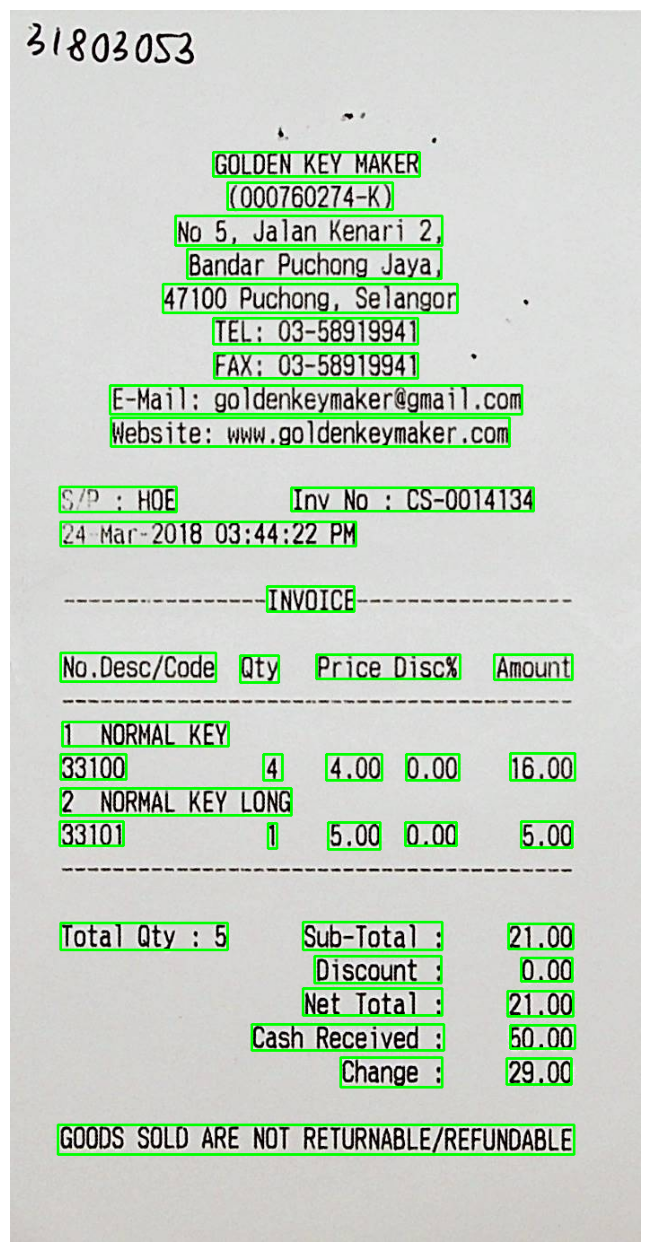

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random


images_dir = "/content/yolo_dataset/images/train"
labels_dir = "/content/yolo_dataset/labels/train"

image_name = random.choice(os.listdir(images_dir))

image_path = os.path.join(images_dir, image_name)

label_path = os.path.join(
    labels_dir,
    os.path.splitext(image_name)[0] + ".txt"
)

image = cv2.imread(image_path)

h, w = image.shape[:2]

# YOLO Labels
with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:

    class_id, xc, yc, bw, bh = map(float, line.split())

    
    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)

    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    # Bounding Box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.9 MB/s eta 0:00:00


In [ ]:
#from ultralytics import YOLO

#model = YOLO("yolo11n.pt")

#results = model.train(
    #data="/content/yolo_dataset/data.yaml",
    #imgsz=640,
    #batch=16,
    #patience=7,
    #optimizer="AdamW",
    #project="/content/runs",
    #name="receipt_detection",
    #seed=42
   # degrees=5.0,       
    # translate=0.05,   
    #scale=0.1,         # Zoom in / out
    #shear=2.0,         
    #perspective=0.0005 # Perspective distortion
#)

In [ ]:

#model=YOLO('/content/runs/receipt_detection/weights/last.pt')
#3results=model.train( data="/content/yolo_dataset/data.yaml",resume=True,epochs=50)

In [ ]:
from ultralytics import YOLO

yolo_model=YOLO('/content/best (3).pt')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
#Evaluate YOLO

metrics = yolo_model.val(
    data="/content/yolo_dataset/data.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3526.3±1533.4 MB/s, size: 361.9 KB)
val: Scanning /content/yolo_dataset/labels/test... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 2.2Kit/s 0.0s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9s/it 9.6s
                   all         71       3686       0.95      0.937      0.959      0.666
Speed: 3.0ms preprocess, 91.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.9504730274670349
Recall: 0.9371631381477502
mAP50: 0.9586515734285068
mAP50-95: 0.6657173063874317



image 1/1 /content/yolo_dataset/images/test/X51007846393.jpg: 640x480 80 texts, 379.2ms
Speed: 14.8ms preprocess, 379.2ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 480)


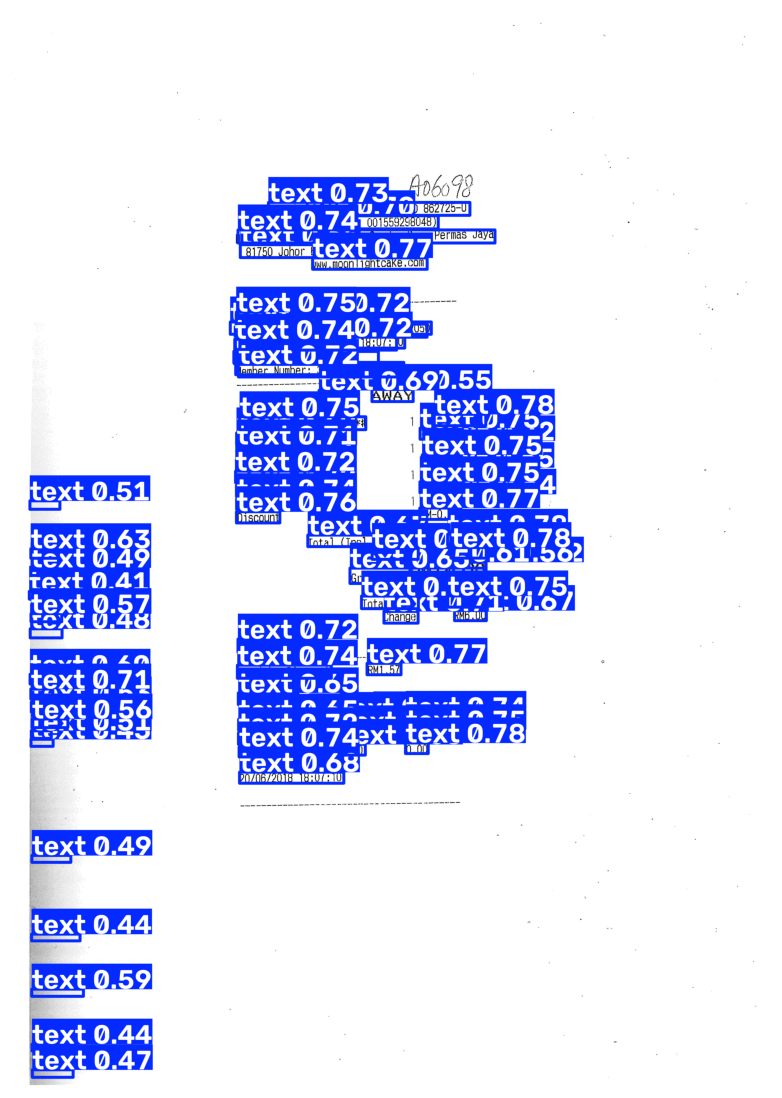

In [ ]:
#test YOLO on one image
import random
import glob
import matplotlib.pyplot as plt

test_images = glob.glob("/content/yolo_dataset/images/test/*.jpg")

image_path = '/content/yolo_dataset/images/test/X51007846393.jpg'
results = yolo_model.predict(
    source=image_path,
    conf=0.4,
    imgsz=640
)

plt.figure(figsize=(10, 14))
plt.imshow(results[0].plot()[..., ::-1])
plt.axis("off")
plt.show()

In [ ]:
!pip install -q paddlepaddle==3.2.2 paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3

In [ ]:
from paddleocr import TextRecognition

recognizer = TextRecognition(
    model_name="en_PP-OCRv4_mobile_rec"
)

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (en_PP-OCRv4_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv4_mobile_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.1 MB/s eta 0:00:00


!Preprocessing

In [ ]:
from jiwer import cer, wer

def normalize_text(text):
    return " ".join(text.upper().split())


In [ ]:
def rotate_90(image, angle):
    if angle == 0:
        return image

    elif angle == 90:
        return cv2.rotate(
            image,
            cv2.ROTATE_90_CLOCKWISE
        )

    elif angle == 180:
        return cv2.rotate(
            image,
            cv2.ROTATE_180
        )

    elif angle == 270:
        return cv2.rotate(
            image,
            cv2.ROTATE_90_COUNTERCLOCKWISE
        )

    return image

In [ ]:
def get_orientation_score(image, max_crops=10):

    result = yolo_model.predict(
        source=image,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    boxes = result.boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        return 0.0

    scores = []

    for box in boxes[:max_crops]:

        x1, y1, x2, y2 = map(int, box)

        h, w = image.shape[:2]

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        results = recognizer.predict(input=crop)

        for res in results:

            text = res["rec_text"].strip()
            score = float(res["rec_score"])

            if text:
                scores.append(score)

    if not scores:
        return 0.0

    return sum(scores) / len(scores)

In [ ]:
def correct_orientation(image):

    candidates = {
        0: image,
        90: rotate_90(image, 90),
        180: rotate_90(image, 180),
        270: rotate_90(image, 270)
    }

    scores = {}

    for angle, candidate in candidates.items():
        scores[angle] = get_orientation_score(candidate)

    best_angle = max(
        scores,
        key=scores.get
    )

    original_score = scores[0]
    best_score = scores[best_angle]

    print("Orientation scores:", scores)
    MIN_IMPROVEMENT = 0.10

    if (
        best_angle != 0
        and best_score > original_score + MIN_IMPROVEMENT
    ):
        print(
            f"Orientation corrected: "
            f"{best_angle} degrees"
        )

        return candidates[best_angle]

    print("Orientation correction not needed")

    return image

In [ ]:
def deskew_image(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )[1]

    coords = np.column_stack(
        np.where(thresh > 0)
    )

    if len(coords) == 0:
        return image

    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    print("Detected skew:", angle)

    # Don't modify an already-straight image
    if abs(angle) < 2:
        return image

    # Don't let deskew handle large rotations
    if abs(angle) > 15:
        return image

    h, w = image.shape[:2]

    center = (
        w // 2,
        h // 2
    )

    matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        image,
        matrix,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated

In [ ]:
def fix_receipt(image):

    # Step 1: fix major orientation
    image = correct_orientation(image)

    # Step 2: fix small skew
    image = deskew_image(image)

    return image

In [ ]:
def get_prediction(image_path):

    # Read original image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Adaptive preprocessing
    image = fix_receipt(image)

    # YOLO prediction on the corrected image
    result = yolo_model.predict(
        source=image,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    # Corrected image used by YOLO
    image = result.orig_img

    boxes = result.boxes.xyxy.cpu().numpy()

    # Sort boxes by vertical center
    boxes = sorted(
        boxes,
        key=lambda box: (box[1] + box[3]) / 2
    )

    lines = []

    for box in boxes:
        x1, y1, x2, y2 = box

        cy = (y1 + y2) / 2
        height = y2 - y1

        placed = False

        for line in lines:
            # Check whether the box belongs to an existing line
            if abs(cy - line["cy"]) < min(height, line["height"]) * 0.5:
                line["boxes"].append(box)
                placed = True
                break

        if not placed:
            lines.append({
                "cy": cy,
                "height": height,
                "boxes": [box]
            })

    # Sort lines from top to bottom
    lines.sort(key=lambda line: line["cy"])

    predicted_lines = []

    for line in lines:

        # Sort boxes from left to right
        line["boxes"].sort(key=lambda box: box[0])

        line_texts = []

        for box in line["boxes"]:

            x1, y1, x2, y2 = map(int, box)

            # Crop the text region
            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            # Recognize text
            results = recognizer.predict(input=crop)

            for res in results:
                text = res["rec_text"]

                if text.strip():
                    line_texts.append(text)

        predicted_lines.append(
            "    ".join(line_texts)
        )

    predicted_text = "\n".join(predicted_lines)

    return predicted_text

In [ ]:
def get_ground_truth(gt_path):
      # 1. Read Ground Truth text and coordinates
      gt_items = []

      with open(gt_path, "r", encoding="utf-8-sig") as f:

          for row in f:

              parts = row.strip().split(",", 8)

              if len(parts) != 9:
                  continue

              try:
                  coords = list(map(int, parts[:8]))
              except ValueError:
                  continue

              text = parts[8].strip()

              if not text:
                  continue

              # Extract X and Y coordinates
              xs = coords[0::2]
              ys = coords[1::2]

              # Convert polygon coordinates to a bounding box
              x1 = min(xs)
              y1 = min(ys)
              x2 = max(xs)
              y2 = max(ys)

              cy = (y1 + y2) / 2
              height = y2 - y1

              gt_items.append({
                  "text": text,
                  "x1": x1,
                  "y1": y1,
                  "x2": x2,
                  "y2": y2,
                  "cy": cy,
                  "height": height
              })


      # 2. Sort text boxes from top to bottom

      gt_items.sort(key=lambda item: item["cy"])


      # 3. Group text boxes into lines

      gt_lines = []

      for item in gt_items:

          cy = item["cy"]
          height = item["height"]

          placed = False

          for line in gt_lines:

              if abs(cy - line["cy"]) < min(height, line["height"]) * 0.5:

                  line["items"].append(item)

                  # Update the vertical center of the line
                  line["cy"] = sum(
                      x["cy"] for x in line["items"]
                  ) / len(line["items"])

                  # Update the representative line height
                  line["height"] = sum(
                      x["height"] for x in line["items"]
                  ) / len(line["items"])

                  placed = True
                  break

          if not placed:

              gt_lines.append({
                  "cy": cy,
                  "height": height,
                  "items": [item]
              })


      # 4. Sort lines from top to bottom

      gt_lines.sort(key=lambda line: line["cy"])


      # 5. Sort text within each line from left to right

      ground_truth_lines = []

      for line in gt_lines:

          line["items"].sort(key=lambda item: item["x1"])

          texts = [
              item["text"]
              for item in line["items"]
          ]

          ground_truth_lines.append(" ".join(texts))


      # 6. Create final Ground Truth text

      ground_truth = "\n".join(ground_truth_lines)
      return ground_truth






Evaluate PaddleOCR

In [ ]:
import os
from jiwer import cer, wer

test_path = "/content/yolo_dataset/images/test"
gt_folder = "/content/SROIE/0325updated.task1train(626p)"

image_files = sorted([
    file for file in os.listdir(test_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of test images:", len(image_files))

Number of test images: 71


In [ ]:
import numpy as np

In [ ]:
results = []

all_ground_truth = []
all_predictions = []

for i, image_file in enumerate(image_files):

    image_path = os.path.join(test_path, image_file)

    image_name = os.path.splitext(image_file)[0]

    gt_path = os.path.join(
        gt_folder,
        image_name + ".txt"
    )

    if not os.path.exists(gt_path):
        print("Missing Ground Truth:", image_file)
        continue

    # YOLO + PaddleOCR
    predicted_text = get_prediction(image_path)

    # Ground Truth
    ground_truth = get_ground_truth(gt_path)

    # Normalize text
    gt = " ".join(ground_truth.upper().split())
    pred = " ".join(predicted_text.upper().split())

    if not gt:
        print("Empty Ground Truth:", image_file)
        continue

    # Calculate CER and WER
    cer_score = cer(gt, pred)
    wer_score = wer(gt, pred)

    results.append({
        "image": image_file,
        "CER": cer_score,
        "WER": wer_score
    })

    all_ground_truth.append(gt)
    all_predictions.append(pred)

    print(
        f"{i + 1}/{len(image_files)} | {image_file} | "
        f"CER: {cer_score * 100:.2f}% | "
        f"WER: {wer_score * 100:.2f}%"
    )

Orientation scores: {0: 0.9840421557426453, 90: 0.6823155164718628, 180: 0.794041845202446, 270: 0.548832181096077}
Orientation correction not needed
Detected skew: -0.37044525146484375
1/71 | X00016469672.jpg | CER: 5.79% | WER: 28.03%
Orientation scores: {0: 0.9684258580207825, 90: 0.4115825990835826, 180: 0.7308200418949127, 270: 0.1668698638677597}
Orientation correction not needed
Detected skew: 0.036012426018714905
2/71 | X51005361900.jpg | CER: 12.97% | WER: 40.58%
Orientation scores: {0: 0.9507204234600067, 90: 0.27381694316864014, 180: 0.6685425738493601, 270: 0.2813027339677016}
Orientation correction not needed
Detected skew: 0.09109019488096237
3/71 | X51005361907.jpg | CER: 32.71% | WER: 55.49%
Orientation scores: {0: 0.9475566506385803, 90: 0.38825042214658523, 180: 0.5136343538761139, 270: 0.42068866118788717}
Orientation correction not needed
Detected skew: 1.2116589546203613
4/71 | X51005361950.jpg | CER: 24.77% | WER: 56.76%
Orientation scores: {0: 0.9607574582099915,

In [ ]:
final_cer = cer(
    "\n".join(all_ground_truth),
    "\n".join(all_predictions)
)

final_wer = wer(
    "\n".join(all_ground_truth),
    "\n".join(all_predictions)
)

print("===== SAMPLE TEST RESULTS =====")
print("Evaluated images:", len(results))
print(f"CER: {final_cer * 100:.2f}%")
print(f"WER: {final_wer * 100:.2f}%")

===== SAMPLE TEST RESULTS =====
Evaluated images: 71
CER: 14.13%
WER: 43.30%


T5 (transformer)

In [ ]:
import os
import json

task1_folder = "/content/SROIE/0325updated.task1train(626p)"
task2_folder = "/content/SROIE/0325updated.task2train(626p)"

task1_files = {
    file for file in os.listdir(task1_folder)
    if file.endswith(".txt")
}

task2_files = {
    file for file in os.listdir(task2_folder)
    if file.endswith(".txt")
}

common_files = sorted(task1_files & task2_files)

dataset = []

for filename in common_files:

    task1_path = os.path.join(task1_folder, filename)
    task2_path = os.path.join(task2_folder, filename)

    # Read Task 1
    receipt_lines = []

    with open(task1_path, "r", encoding="utf-8-sig") as f:

        for row in f:

            parts = row.strip().split(",", 8)

            if len(parts) != 9:
                continue

            text = parts[8].strip()

            if text:
                receipt_lines.append(text)

    input_text = " ".join(receipt_lines)


    # Read Task 2
    with open(task2_path, "r", encoding="utf-8-sig") as f:
        labels = json.load(f)


    # Create target
    target_text = (
        "company: " + labels.get("company", "") +
        " address: " + labels.get("address", "") +
        " date: " + labels.get("date", "") +
        " total: " + labels.get("total", "")
    )


    dataset.append({
        "filename": filename,
        "input_text": input_text,
        "target_text": target_text
    })

In [ ]:
print("Number of receipts:", len(dataset))

print("\nINPUT:")
print(dataset[0]["input_text"])

print("\nTARGET:")
print(dataset[0]["target_text"])

Number of receipts: 716

INPUT:
TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 789417-W NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR. DOCUMENT NO : TD01167104 DATE: 25/12/2018 8:13:39 PM CASHIER: MANIS MEMBER: CASH BILL CODE/DESC PRICE DISC AMOUNT QTY RM RM 9556939040116 KF MODELLING CLAY KIDDY FISH 1 PC * 9.000 0.00 9.00 TOTAL: ROUR DING ADJUSTMENT: 0.00 ROUND D TOTAL (RM): 9.00 CASH 10.00 CHANGE 1.00 GOODS SOLD ARE NOT RETURNABLE OR EXCHANGEABLE *** *** THANK YOU PLEASE COME AGAIN ! 9.00

TARGET:
company: BOOK TA .K (TAMAN DAYA) SDN BHD address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR. date: 25/12/2018 total: 9.00


In [ ]:
import os

train_image_folder = "/content/yolo_dataset/images/train"
val_image_folder = "/content/yolo_dataset/images/val"
test_image_folder = "/content/yolo_dataset/images/test"

train_ids = {
    os.path.splitext(file)[0]
    for file in os.listdir(train_image_folder)
}

val_ids = {
    os.path.splitext(file)[0]
    for file in os.listdir(val_image_folder)
}

test_ids = {
    os.path.splitext(file)[0]
    for file in os.listdir(test_image_folder)
}

In [ ]:
train_data = []
val_data = []
test_data = []
unmatched_data = []

for sample in dataset:

    receipt_id = os.path.splitext(sample["filename"])[0]

    if receipt_id in train_ids:
        train_data.append(sample)

    elif receipt_id in val_ids:
        val_data.append(sample)

    elif receipt_id in test_ids:
        test_data.append(sample)

    else:
        unmatched_data.append(sample)

In [ ]:
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))
print("Unmatched:", len(unmatched_data))

Train: 531
Validation: 68
Test: 68
Unmatched: 49


In [ ]:
train_data.extend(unmatched_data)

print("Final Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
#Get the max length of the input text
lengths = []

for sample in train_data:

    encoded = tokenizer(
        sample["input_text"],
        truncation=False
    )

    lengths.append(len(encoded["input_ids"]))

print("Minimum:", min(lengths))
print("Maximum:", max(lengths))
print("Average:", sum(lengths) / len(lengths))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (514 > 512). Running this sequence through the model will result in indexing errors


Minimum: 89
Maximum: 671
Average: 316.5065913370998


In [ ]:
import numpy as np

print("90%:", np.percentile(lengths, 90))
print("95%:", np.percentile(lengths, 95))
print("99%:", np.percentile(lengths, 99))

90%: 450.0
95%: 473.5
99%: 581.9000000000003


In [ ]:
over_512 = sum(length > 512 for length in lengths)

print("Receipts over 512:", over_512)
print("Percentage:", over_512 / len(lengths) * 100)

Receipts over 512: 13
Percentage: 2.4482109227871938


In [ ]:
def prepare_input(text):

    tokens = tokenizer(
        text,
        truncation=False,
        add_special_tokens=False
    )["input_ids"]

    if len(tokens) <= 511:
        final_tokens = tokens

    else:
        first_part = tokens[:350]
        last_part = tokens[-161:]

        final_tokens = first_part + last_part

    final_tokens.append(tokenizer.eos_token_id)

    return final_tokens

In [ ]:

new_lengths = []

for sample in train_data:

    input_ids = prepare_input(sample["input_text"])

    new_lengths.append(len(input_ids))

print("Maximum:", max(new_lengths))
print("Minimum:", min(new_lengths))

Maximum: 512
Minimum: 89


In [ ]:
#Get the max length of the target text
target_lengths = []

for sample in train_data:

    encoded = tokenizer(
        sample["target_text"],
        truncation=False
    )

    target_lengths.append(len(encoded["input_ids"]))

print("Minimum:", min(target_lengths))
print("Maximum:", max(target_lengths))
print("Average:", sum(target_lengths) / len(target_lengths))

Minimum: 29
Maximum: 89
Average: 63.22975517890772


In [ ]:
import numpy as np

print("90%:", np.percentile(target_lengths, 90))
print("95%:", np.percentile(target_lengths, 95))
print("99%:", np.percentile(target_lengths, 99))

90%: 79.0
95%: 82.0
99%: 83.70000000000005


In [ ]:
max_target_length = 96

def prepare_target(text):

    encoded = tokenizer(
        text,
        max_length=max_target_length,
        truncation=True
    )

    return encoded["input_ids"]

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)
test_dataset = Dataset.from_list(test_data)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['filename', 'input_text', 'target_text'],
    num_rows: 531
})
Dataset({
    features: ['filename', 'input_text', 'target_text'],
    num_rows: 68
})
Dataset({
    features: ['filename', 'input_text', 'target_text'],
    num_rows: 68
})


In [ ]:


def preprocess_function(example):

    input_ids = prepare_input(example["input_text"])

    target = prepare_target(example['target_text'])

    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids),
        "labels": target
    }

In [ ]:
tokenized_train = train_dataset.map(
    preprocess_function,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    preprocess_function,
    remove_columns=val_dataset.column_names
)

tokenized_test = test_dataset.map(
    preprocess_function,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_train)
print(tokenized_train[0])

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 531
})
{'input_ids': [3, 25950, 3, 16733, 4170, 3, 476, 21478, 3, 25793, 3, 3221, 3, 5, 439, 599, 3221, 9312, 3, 12860, 188, 61, 180, 12145, 272, 10604, 3, 3940, 4240, 2517, 18, 518, 5693, 5, 4867, 6897, 6, 3436, 3, 184, 3, 3390, 6, 3, 13853, 12303, 4646, 13961, 14985, 3, 3221, 9312, 3, 12860, 188, 6, 3, 4959, 2915, 446, 9195, 2990, 272, 14084, 8503, 6, 446, 9195, 2990, 5, 6054, 5211, 11810, 5693, 3, 10, 3, 10494, 4542, 27650, 15442, 309, 6048, 10, 944, 18009, 21912, 505, 10, 2368, 10, 3288, 3246, 205, 21337, 18988, 10, 3, 9312, 4555, 283, 6037, 12920, 10, 205, 21337, 272, 10781, 2847, 5596, 87, 18284, 254, 6045, 8906, 3, 15438, 254, 71, 5365, 17161, 1593, 12016, 3, 7336, 3, 7336, 11923, 4834, 4271, 2394, 2445, 20159, 480, 371, 24259, 12735, 2365, 205, 29002, 480, 4309, 19409, 377, 20619, 209, 2104, 1429, 5835, 2313, 3, 10667, 3, 28308, 3001, 16359, 10, 391, 9131, 309, 2365, 8502, 683, 16847, 11810, 10, 3,

In [ ]:
#padding
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [ ]:
#example on applying padding on 2 samples
samples = [
    tokenized_train[0],
    tokenized_train[1]
]

batch = data_collator(samples)

print("Input shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["labels"].shape)

Input shape: torch.Size([2, 299])
Attention mask shape: torch.Size([2, 299])
Labels shape: torch.Size([2, 70])


In [ ]:
import re

def parse_output(text):

    fields = {
        "company": "",
        "address": "",
        "date": "",
        "total": ""
    }

    pattern = (
        r"company:\s*(.*?)\s*"
        r"address:\s*(.*?)\s*"
        r"date:\s*(.*?)\s*"
        r"total:\s*(.*)"
    )

    match = re.search(pattern, text, re.IGNORECASE)

    if match:
        fields["company"] = match.group(1).strip()
        fields["address"] = match.group(2).strip()
        fields["date"] = match.group(3).strip()
        fields["total"] = match.group(4).strip()

    return fields

In [ ]:
def normalize_field(text):

    text = text.upper()
    text = " ".join(text.split())

    return text

In [ ]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)
    labels = np.asarray(labels)

    predictions = np.where(
        predictions < 0,
        tokenizer.pad_token_id,
        predictions
    )

    labels = np.where(
        labels == -100,
        tokenizer.pad_token_id,
        labels
    )

    predictions = predictions.astype(np.int64)
    labels = labels.astype(np.int64)

    decoded_predictions = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    correct = {
        "company": 0,
        "address": 0,
        "date": 0,
        "total": 0
    }

    for prediction, label in zip(
        decoded_predictions,
        decoded_labels
    ):

        pred_fields = parse_output(prediction)
        true_fields = parse_output(label)

        for field in correct:

            pred_value = normalize_field(
                pred_fields[field]
            )

            true_value = normalize_field(
                true_fields[field]
            )

            if pred_value == true_value:
                correct[field] += 1

    total_samples = len(decoded_predictions)

    return {
        "company_accuracy": correct["company"] / total_samples,
        "address_accuracy": correct["address"] / total_samples,
        "date_accuracy": correct["date"] / total_samples,
        "total_accuracy": correct["total"] / total_samples
    }

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/t5_receipt_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=5e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=3,

    weight_decay=0.01,

    predict_with_generate=True,
    generation_max_length=96,

    logging_steps=20,

    save_total_limit=2,

    load_best_model_at_end=True
)

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

In [ ]:
test_results = trainer.evaluate(
    eval_dataset=tokenized_test
)

print(test_results)

In [ ]:
import torch

In [ ]:
!unzip /content/final_t5_receipt_model.zip -d /content/final_t5_receipt_model

Archive:  /content/final_t5_receipt_model.zip
  inflating: /content/final_t5_receipt_model/training_args.bin  
  inflating: /content/final_t5_receipt_model/model.safetensors  
  inflating: /content/final_t5_receipt_model/config.json  
  inflating: /content/final_t5_receipt_model/tokenizer_config.json  
  inflating: /content/final_t5_receipt_model/tokenizer.json  
  inflating: /content/final_t5_receipt_model/generation_config.json  


In [ ]:
!unzip /content/final_t5_receipt_model_v2.zip  -d /content/final_t5_receipt_model_v2

Archive:  /content/final_t5_receipt_model_v2.zip
   creating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/training_args.bin  
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/model.safetensors  
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/config.json  
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/tokenizer_config.json  
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/tokenizer.json  
  inflating: /content/final_t5_receipt_model_v2/content/final_t5_receipt_model_v2/generation_config.json  


Baseline T5 Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_path = '/content/final_t5_receipt_model'

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)
model.eval()

print("T5 V1 loaded successfully")
print("Device:", device)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5 V2 loaded successfully
Device: cuda


In [ ]:
test_args = Seq2SeqTrainingArguments(
    output_dir="/content/t5_test_results",

    per_device_eval_batch_size=4,

    predict_with_generate=True,

    generation_max_length=96,

    report_to="none"
)

In [ ]:
test_trainer = Seq2SeqTrainer(
    model=model,
    args=test_args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
test_results = test_trainer.evaluate(
     eval_dataset=tokenized_test
)

test_results

Training Loss,Validation Loss,Step,Company Accuracy,Address Accuracy,Date Accuracy,Total Accuracy
No log,0.109587,0,0.838235,0.602941,0.955882,0.867647


{'eval_loss': 0.1095869243144989,
 'eval_company_accuracy': 0.8382352941176471,
 'eval_address_accuracy': 0.6029411764705882,
 'eval_date_accuracy': 0.9558823529411765,
 'eval_total_accuracy': 0.8676470588235294}

In [ ]:
print(
    f"Company Accuracy: "
    f"{test_results['eval_company_accuracy'] * 100:.2f}%"
)

print(
    f"Address Accuracy: "
    f"{test_results['eval_address_accuracy'] * 100:.2f}%"
)

print(
    f"Date Accuracy: "
    f"{test_results['eval_date_accuracy'] * 100:.2f}%"
)

print(
    f"Total Accuracy: "
    f"{test_results['eval_total_accuracy'] * 100:.2f}%"
)

Company Accuracy: 83.82%
Address Accuracy: 60.29%
Date Accuracy: 95.59%
Total Accuracy: 86.76%


In [ ]:
def extract_information(ocr_text):

    input_ids = prepare_input(ocr_text)

    input_ids = torch.tensor(
        [input_ids]
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=96
        )

    result = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return result

In [ ]:
import os
import json

correct = {
    "company": 0,
    "address": 0,
    "date": 0,
    "total": 0
}

total_samples = 0
end_to_end_results = []

test_images = sorted([
    file
    for file in os.listdir(test_image_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

for i, image_name in enumerate(test_images):

    print(f"Processing {i+1}/{len(test_images)}: {image_name}")

    # -------------------------
    # 1. Image -> YOLO + OCR
    # -------------------------
    image_path = os.path.join(
        test_image_folder,
        image_name
    )

    ocr_text = get_prediction(image_path)

    # -------------------------
    # 2. OCR text -> T5
    # -------------------------
    t5_output = extract_information(ocr_text)

    pred_fields = parse_output(t5_output)

    # -------------------------
    # 3. Load Task2 GT
    # -------------------------
    receipt_id = os.path.splitext(image_name)[0]

    gt_path = os.path.join(
        task2_folder,
        receipt_id + ".txt"
    )

    if not os.path.exists(gt_path):
        print("Ground truth not found:", receipt_id)
        continue

    with open(
        gt_path,
        "r",
        encoding="utf-8-sig"
    ) as f:
        true_fields = json.load(f)

    # -------------------------
    # 4. Compare fields
    # -------------------------
    sample_result = {
        "filename": image_name,
        "ocr_text": ocr_text,
        "t5_output": t5_output
    }

    for field in correct:

        pred_value = normalize_field(
            pred_fields.get(field, "")
        )

        true_value = normalize_field(
            true_fields.get(field, "")
        )

        is_correct = pred_value == true_value

        if is_correct:
            correct[field] += 1

        sample_result[field + "_pred"] = pred_value
        sample_result[field + "_true"] = true_value
        sample_result[field + "_correct"] = is_correct

    end_to_end_results.append(sample_result)

    total_samples += 1

Processing 1/71: X00016469672.jpg
Orientation scores: {0: 0.9840421557426453, 90: 0.6823155164718628, 180: 0.794041845202446, 270: 0.548832181096077}
Orientation correction not needed
Detected skew: -0.37044525146484375


[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processing 2/71: X51005361900.jpg
Orientation scores: {0: 0.9684258580207825, 90: 0.4115825990835826, 180: 0.7308200418949127, 270: 0.1668698638677597}
Orientation correction not needed
Detected skew: 0.036012426018714905


[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processing 3/71: X51005361907.jpg
Orientation scores: {0: 0.9507204234600067, 90: 0.27381694316864014, 180: 0.6685425738493601, 270: 0.2813027339677016}
Orientation correction not needed
Detected skew: 0.09109019488096237


...

[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processing 70/71: X51008164525.jpg
Orientation scores: {0: 0.9616544663906097, 90: 0.4376432433724403, 180: 0.4885438919067383, 270: 0.6405877135694027}
Orientation correction not needed
Detected skew: -0.0


[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processing 71/71: X51008164991.jpg
Orientation scores: {0: 0.9832199692726136, 90: 0.3394213989377022, 180: 0.6014564812183381, 270: 0.498630177643564}
Orientation correction not needed
Detected skew: -0.0


[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
sample = end_to_end_results[0]

print("FILE:")
print(sample["filename"])

print("\nOCR:")
print(sample["ocr_text"])

print("\nT5 OUTPUT:")
print(sample["t5_output"])

print("\nCOMPANY:")
print("Pred:", sample["company_pred"])
print("True:", sample["company_true"])
print("Correct:", sample["company_correct"])

print("\nADDRESS:")
print("Pred:", sample["address_pred"])
print("True:", sample["address_true"])
print("Correct:", sample["address_correct"])

print("\nDATE:")
print("Pred:", sample["date_pred"])
print("True:", sample["date_true"])
print("Correct:", sample["date_correct"])

print("\nTOTAL:")
print("Pred:", sample["total_pred"])
print("True:", sample["total_true"])
print("Correct:", sample["total_correct"])

FILE:
X00016469672.jpg

OCR:
POR
tan chay yee
SOON HUAT MACHINERY ENTERPRISE
JM0352019-K
NO.53 JALAN PUTRA 1,
TAMAN SRIPUTRA,
81200JOHOR BAHRU
JOHOR
TEL07-5547360/016-799339    FAX07-5624059
SOONHUAT2000@HOTMAIL.COM
GSTID002116837376
CASHSALES
Doc No    CS00004040    Date:11/01/2019
Cashier    USER    Time:09:44:00
Salesperson    Ref.:
Item    Qty    S/Price    S/Price    Amount    Tax
1072    1    80.00    80.00    80.00
REPAIR ENGINE POWER SPRAYER (1UNIT)
workmanship & service
70549    1    160.00    160.00    160.00
GIANT 606 OVERFLOW ASSY
1071    1    17.00    17.00    17.00
ENGINE OIL
70791    1    1.    10.00    10.00    10.00
GREASE FOR TOOLS4OML (AKODA)
70637    1    6.00    6.00    6.00
EY20PLUG CHAMPION
1643    1    8.00    8.00    8.00
STARTER TALI
70197    1    10.00    10.00    10.00
EY20STARTER HANDLE
70561    2    18.00    18.00    36.00
HD40 1LCOTIN
Total Qty    9    32700
Total Sales    327.00
Discount    0.00
Total    0.00
Rounding    0.00
Total Sales    327.00
CASH  

In [ ]:
print("\nEND-TO-END TEST RESULTS")
print("-----------------------")

for field in correct:

    accuracy = correct[field] / total_samples

    print(
        f"{field.capitalize()} Accuracy: "
        f"{accuracy * 100:.2f}% "
        f"({correct[field]}/{total_samples})"
    )


END-TO-END TEST RESULTS
-----------------------
Company Accuracy: 29.41% (20/68)
Address Accuracy: 1.47% (1/68)
Date Accuracy: 82.35% (56/68)
Total Accuracy: 66.18% (45/68)


In [ ]:
from jiwer import cer

for field in correct:

    all_true = []
    all_pred = []

    for sample in end_to_end_results:

        true = normalize_field(
            sample[field + "_true"]
        )

        pred = normalize_field(
            sample[field + "_pred"]
        )

        all_true.append(true)
        all_pred.append(pred)

    score = cer(
        "\n".join(all_true),
        "\n".join(all_pred)
    )

    print(
        f"{field.capitalize()} CER: "
        f"{score * 100:.2f}%"
    )

Company CER: 17.85%
Address CER: 26.65%
Date CER: 12.46%
Total CER: 17.06%


In [ ]:
def process_receipt(image_path):

    # 1. Detection + OCR
    ocr_text = get_prediction(image_path)

    # 2. Information Extraction
    t5_output = extract_information(ocr_text)

    # 3. Parse T5 output
    fields = parse_output(t5_output)

    return {
        "company": fields["company"],
        "address": fields["address"],
        "date": fields["date"],
        "total": fields["total"],
        "ocr_text": ocr_text
    }

In [ ]:
result = process_receipt(image_path)

print("Company:", result["company"])
print("Address:", result["address"])
print("Date:", result["date"])
print("Total:", result["total"])

print("\nOCR Text:")
print(result["ocr_text"])

Orientation scores: {0: 0.9832199692726136, 90: 0.3394213989377022, 180: 0.6014564812183381, 270: 0.498630177643564}
Orientation correction not needed
Detected skew: -0.0


[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Company: ONE ONE THREE SEAFOOD RESTAURANT SDN BHD
Address: NO.1TAMAN SRI DENGKILJALAN AIR HITAM 43800 DENGKILSELANGOR
Date: 13-06-2018
Total: 35.00

OCR Text:
ONE ONE THREE SEAFOOD RESTAURANT SDN BHD
1120908-M
NO.1TAMAN SRI DENGKILJALAN AIR HITAM
43800 DENGKILSELANGOR
GST Reg.No000670224384
TaxInvoice
Table37
B111#V001-540338    Order#140447
Date    ate13-06-201822:53:19
Cashier113 CASHIER    Paxs    0
Qty    Description    TotalTAX
D    15.00SR
Rice w Seafood /Meat Item Single
1    D    5.00SR
Beverage
1    D    15.00SR
Noodle Item Single
TotalExcludingGST    35.00
Total(Inclusive of GST:    35.00
TOTAL:    35.00
Closed:1    13-06-2018    23:12:13
Server113 CASHIER
CASH    35.00
GST Sumnary    AmountRM    TaxRM
SR    @0%    35.00    0.00
**** Thank You ++**
Please Come Again


Link with more data

In [ ]:
!wget -q https://huggingface.co/datasets/mankind1023/receipt-dataset-standardized/resolve/main/receipt_dataset_2780.tgz \
-O /content/receipt_dataset_2780.tgz

In [ ]:
!mkdir -p /content/receipt_standardized

!tar -xzf /content/receipt_dataset_2780.tgz \
-C /content/receipt_standardized

In [ ]:
import os

base_path = "/content/receipt_standardized"

print(os.listdir(base_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/receipt_standardized'

In [ ]:
import os
from collections import Counter

receipts_path = "/content/receipt_standardized/receipts"

files = os.listdir(receipts_path)

sources = []

for filename in files:

    if filename.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        source = filename.split("_")[0]

        sources.append(source)

print(Counter(sources))

In [ ]:
import os

annotations_path = "/content/receipt_standardized/annotations"

annotation_files = os.listdir(
    annotations_path
)

print("Number of annotations:", len(annotation_files))
print(annotation_files[:10])

In [ ]:
import json

sources = [
    "zenodo",
    "cord",
    "express",
    "sroie"
]

for source in sources:

    file = next(
        (
            f for f in annotation_files
            if f.startswith(source + "_")
            and f.endswith(".json")
        ),
        None
    )

    print("\n" + "=" * 80)
    print("SOURCE:", source)
    print("FILE:", file)

    if file:

        path = os.path.join(
            annotations_path,
            file
        )

        with open(
            path,
            "r",
            encoding="utf-8"
        ) as f:

            data = json.load(f)

        print(json.dumps(
            data,
            indent=2,
            ensure_ascii=False
        ))

In [ ]:
import os
import json

annotations_path = "/content/receipt_standardized/annotations"

external_pairs = []

for filename in os.listdir(annotations_path):

    if not filename.endswith(".json"):
        continue

    # Only Zenodo and Express
    if not (
        filename.startswith("zenodo_")
        or filename.startswith("express_")
    ):
        continue

    path = os.path.join(
        annotations_path,
        filename
    )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:
        data = json.load(f)

    company = data.get(
        "merchant", {}
    ).get("name", "").strip()

    address = data.get(
        "merchant", {}
    ).get("address", "").strip()

    date = data.get(
        "transaction", {}
    ).get("date", "").strip()

    total = data.get(
        "transaction", {}
    ).get("total", None)

    input_text = data.get(
        "ocr_raw", {}
    ).get("full_text", "").strip()

    # Keep only complete samples
    if not company or not address or not date:
        continue

    if total is None:
        continue

    if not input_text:
        continue

    target_text = (
        f"company: {company} "
        f"address: {address} "
        f"date: {date} "
        f"total: {total}"
    )

    external_pairs.append({
        "input_text": input_text,
        "target_text": target_text
    })


print("Valid external samples:", len(external_pairs))

print("\nExample input:")
print(external_pairs[0]["input_text"])

print("\nExample target:")
print(external_pairs[0]["target_text"])

In [ ]:
print("Original SROIE train:", len(train_data))
print("External samples:", len(external_pairs))

new_train_pairs = train_data + external_pairs

print("New training size:", len(new_train_pairs))

In [ ]:
import random

random.seed(42)
random.shuffle(new_train_pairs)

In [ ]:
from datasets import Dataset

new_train_dataset = Dataset.from_list(new_train_pairs)

print(new_train_dataset)
print(new_train_dataset[0])

In [ ]:
new_tokenized_train = new_train_dataset.map(
    preprocess_function,
    remove_columns=new_train_dataset.column_names
)

print(new_tokenized_train)

Improved T5 V2 with External Training Data

In [ ]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(
    "t5-small"
)

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/t5_receipt_external",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=5e-4,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=10,

    weight_decay=0.01,

    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_strategy="epoch",

    report_to="none",

)

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=new_tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,
    data_collator=data_collator
)

In [ ]:
trainer.train()

In [ ]:
!zip -r /content/final_t5_receipt_model_v2.zip /content/final_t5_receipt_model_v2

In [ ]:
from google.colab import files

files.download(
    "/content/final_t5_receipt_model_v2.zip"
)

In [ ]:
trainer.args.predict_with_generate = True

In [ ]:
trainer.compute_metrics = compute_metrics

In [ ]:
test_results = trainer.evaluate(
    eval_dataset=tokenized_test,
    max_new_tokens=96
)

print(test_results)

In [ ]:
model_path = "/content/final_t5_receipt_model_v2"

tokenizer = AutoTokenizer.from_pretrained(
    model_path
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_path
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)
model.eval()

print("T5 V2 loaded successfully")
print("Device:", device)

In [ ]:
test_trainer = Seq2SeqTrainer(
    model=model,
    args=test_args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
test_results = test_trainer.evaluate(
    eval_dataset=tokenized_test,
    max_new_tokens=96
)

print(test_results)